# ***SWARM ROBOTICS RESEARCH PROJECT***
# Obstacle Entrapment and Search Efficiency Study
#
# Author: Vivyn Kilari
#
# This notebook compares:
# 1. Stochastic Levy-Flight Navigation
# 2. Gradient-Based Artificial Potential Field Navigation

# Goal:
# Investigate how obstacle-rich environments affect
# swarm robot search performance.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [17]:
pip install matplotlib seaborn scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# Better plotting style
plt.style.use("ggplot")

In [19]:
# Random seed for reproducibility
np.random.seed(42)

In [20]:
# ENVIRONMENT PARAMETERS

ARENA_DIM = 100.0

TARGET_RADIUS = 3.5

ROBOT_COUNT = 15

MAX_ITERATIONS = 1200

TRIAL_COUNT = 30

TARGET_POSITION = np.array([85.0, 85.0])

OBSTACLE_BOUNDS = [
    [40, 60, 20, 80]
]

print("Environment initialized successfully.")

Environment initialized successfully.


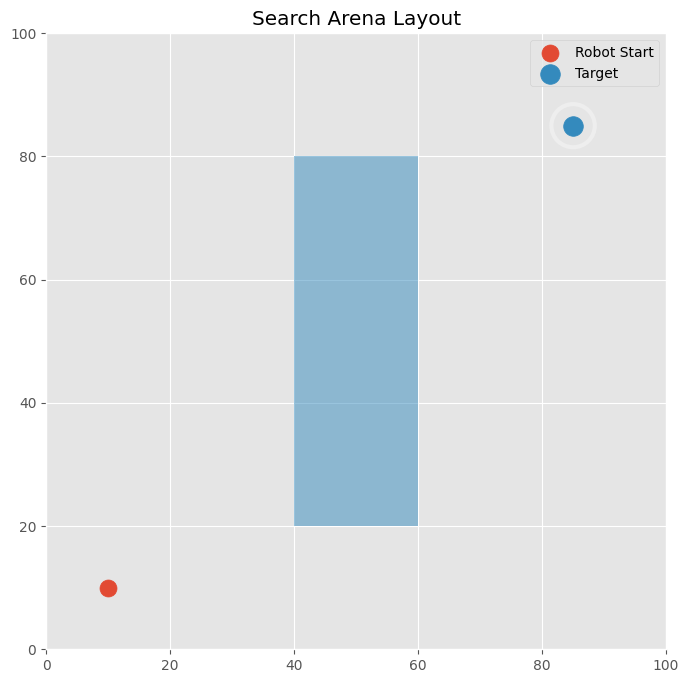

In [21]:
# VISUALIZATION OF EXPERIMENTAL ENVIRONMENT

fig, ax = plt.subplots(figsize=(8,8))

ax.set_xlim(0, ARENA_DIM)
ax.set_ylim(0, ARENA_DIM)

# Obstacle
for obs in OBSTACLE_BOUNDS:
    x1,x2,y1,y2 = obs

    rect = plt.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        alpha=0.5
    )

    ax.add_patch(rect)

# Start position
ax.scatter(
    10,
    10,
    s=150,
    label="Robot Start"
)

# Target
circle = plt.Circle(
    TARGET_POSITION,
    TARGET_RADIUS,
    fill=False,
    linewidth=3
)

ax.add_patch(circle)

ax.scatter(
    TARGET_POSITION[0],
    TARGET_POSITION[1],
    s=200,
    label="Target"
)

plt.title("Search Arena Layout")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# ==========================================================
# ROBOT AGENT DEFINITION
# ==========================================================

class Robot:

    def __init__(self, robot_id, start_pos):

        self.robot_id = robot_id

        self.pos = np.array(start_pos, dtype=float)

        self.path = [self.pos.copy()]

        self.found_target = False

    def move(self, movement_vector, obstacles):

        new_pos = self.pos + movement_vector

        # Arena boundary enforcement
        new_pos = np.clip(
            new_pos,
            0,
            ARENA_DIM
        )

        # Obstacle collision checking
        for obs in obstacles:

            x1,x2,y1,y2 = obs

            inside_obstacle = (
                x1 <= new_pos[0] <= x2 and
                y1 <= new_pos[1] <= y2
            )

            if inside_obstacle:
                return

        self.pos = new_pos

        self.path.append(
            self.pos.copy()
        )

In [23]:
# MAIN SIMULATION FUNCTION

def run_simulation(search_type="stochastic"):

    robots = [
        Robot(i,[10,10])
        for i in range(ROBOT_COUNT)
    ]

    discovery_step = -1

    for step in range(MAX_ITERATIONS):

        for robot in robots:

            # --------------------------------------
            # STOCHASTIC LEVY-FLIGHT SEARCH
            # --------------------------------------
            if search_type == "stochastic":

                step_size = np.random.rayleigh(1.5)

                angle = np.random.uniform(
                    0,
                    2*np.pi
                )

                move_vector = np.array([
                    np.cos(angle),
                    np.sin(angle)
                ]) * step_size

            # --------------------------------------
            # GRADIENT SEARCH
            # --------------------------------------
            else:

                direction = (
                    TARGET_POSITION
                    - robot.pos
                )

                distance = np.linalg.norm(
                    direction
                )

                if distance > 0:
                    unit_vector = (
                        direction /
                        distance
                    )
                else:
                    unit_vector = np.zeros(2)

                move_vector = (
                    unit_vector*1.2
                    +
                    np.random.normal(
                        0,
                        0.4,
                        2
                    )
                )

            robot.move(
                move_vector,
                OBSTACLE_BOUNDS
            )

            if np.linalg.norm(
                robot.pos
                -
                TARGET_POSITION
            ) < TARGET_RADIUS:

                discovery_step = step

                robot.found_target = True

                break

        if discovery_step != -1:
            break

    return discovery_step if discovery_step != -1 else MAX_ITERATIONS

In [24]:
# EXECUTE RESEARCH TRIALS

print("Running research experiments...")

stochastic_results = [
    run_simulation("stochastic")
    for _ in range(TRIAL_COUNT)
]

gradient_results = [
    run_simulation("gradient")
    for _ in range(TRIAL_COUNT)
]

print("Completed.")

Running research experiments...
Completed.


In [25]:
# DESCRIPTIVE STATISTICS

s_mean = np.mean(stochastic_results)
s_std = np.std(stochastic_results)

g_mean = np.mean(gradient_results)
g_std = np.std(gradient_results)

print("\nSTOCHASTIC SEARCH")
print("---------------------")
print(f"Mean      : {s_mean:.2f}")
print(f"Std Dev   : {s_std:.2f}")

print("\nGRADIENT SEARCH")
print("---------------------")
print(f"Mean      : {g_mean:.2f}")
print(f"Std Dev   : {g_std:.2f}")


STOCHASTIC SEARCH
---------------------
Mean      : 1161.23
Std Dev   : 95.20

GRADIENT SEARCH
---------------------
Mean      : 1200.00
Std Dev   : 0.00


In [ ]:
# HISTOGRAM COMPARISON

plt.figure(figsize=(10,6))

plt.hist(
    stochastic_results,
    bins=15,
    alpha=0.7,
    label="Stochastic"
)

plt.hist(
    gradient_results,
    bins=15,
    alpha=0.7,
    label="Gradient"
)

plt.xlabel("Discovery Steps")
plt.ylabel("Frequency")
plt.title("Distribution of Discovery Times")

plt.legend()
plt.show()

In [ ]:
# VIOLIN PLOT

plt.figure(figsize=(8,6))

sns.violinplot(
    data=[
        stochastic_results,
        gradient_results
    ]
)

plt.xticks(
    [0,1],
    ["Stochastic","Gradient"]
)

plt.ylabel("Discovery Steps")

plt.title(
    "Discovery Time Distribution"
)

plt.show()

In [ ]:
# BOXPLOT COMPARISON

plt.figure(figsize=(8,6))

plt.boxplot(
    [
        stochastic_results,
        gradient_results
    ],
    labels=[
        "Stochastic",
        "Gradient"
    ]
)

plt.ylabel("Discovery Steps")

plt.title(
    "Search Efficiency Comparison"
)

plt.show()